# OIBSIP Task 2 – Customer Segmentation Analysis

**Author:** Data Analytics Intern  
**Project:** Oasis InfoByte Data Analytics Internship Program (OIBSIP) - Task 2  
**Domain:** E-Commerce & Retail Customer Analytics  
**Dataset:** UCI Online Retail Transaction Dataset  
**Notebook Name:** `Task2_Customer_Segmentation.ipynb`  
---

## 1. Project Introduction & Business Context

### What is Customer Segmentation?
Customer segmentation is the process of dividing a company's customer base into distinct, homogeneous groups based on shared behavioral, transactional, or demographic characteristics. Rather than treating all customers uniformly, segmentation enables businesses to understand the unique purchasing habits and value drivers of different consumer groups.

### Why Do Businesses Use Customer Segmentation?
- **Targeted Marketing Campaigns:** Tailor promotional messaging, offers, and channels to specific customer profiles, maximizing Conversion Rates and Return on Ad Spend (ROAS).
- **Customer Retention & Churn Prevention:** Proactively identify at-risk or inactive buyers and deploy automated re-engagement workflows before churn occurs.
- **Resource & Budget Optimization:** Focus high-touch VIP services and expensive loyalty incentives on high-value customer segments (Champions).
- **Product & Pricing Strategy:** Identify cross-selling and upselling opportunities based on spending capability and order frequency.

### The RFM Framework (Recency, Frequency, Monetary)
RFM analysis evaluates customer behavior across three core dimensions:
1. **Recency ($R$):** Days elapsed since the customer's most recent transaction. Lower recency indicates active engagement.
2. **Frequency ($F$):** Total number of distinct completed orders/invoices. Higher frequency indicates strong brand loyalty.
3. **Monetary ($M$):** Total gross dollar revenue generated by the customer. Higher monetary value indicates high financial contribution.

### Unsupervised Machine Learning with K-Means
By standardizing RFM features and applying **K-Means Clustering**, we partition customers into natural clusters based on distance metrics in feature space, enabling automated, objective customer profiling.

In [1]:
# Import required data analysis, machine learning, and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set visualization parameters
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.autolayout'] = True

# Suppress non-critical warnings
import warnings
warnings.filterwarnings('ignore')

print("All required libraries successfully imported.")

All required libraries successfully imported.


## 2. Load and Inspect Dataset

In [2]:
# Define dataset path and load data
dataset_path = '../data/online_retail.csv' if os.path.exists('../data/online_retail.csv') else 'data/online_retail.csv'
df = pd.read_csv(dataset_path, encoding='ISO-8859-1')

print(f"Dataset successfully loaded from: {dataset_path}")

Dataset successfully loaded from: ../data/online_retail.csv


In [3]:
# Display first 5 rows
print("--- FIRST 5 ROWS ---")
df.head()

--- FIRST 5 ROWS ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Display last 5 rows
print("--- LAST 5 ROWS ---")
df.tail()

--- LAST 5 ROWS ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [5]:
# Display dataset dimensions (shape)
print(f"Dataset Dimensions: {df.shape[0]:,} rows, {df.shape[1]} columns")

Dataset Dimensions: 541,909 rows, 8 columns


In [6]:
# Display column names and data types
print("--- COLUMN NAMES & DATA TYPES ---")
df.info()

--- COLUMN NAMES & DATA TYPES ---
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [7]:
# Check missing values
print("--- MISSING VALUES COUNT ---")
missing = df.isnull().sum()
print(missing)

--- MISSING VALUES COUNT ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates:,}")

Total Duplicate Rows: 5,268


In [9]:
# Display basic descriptive statistics for numerical columns
print("--- NUMERICAL DESCRIPTIVE STATISTICS ---")
df.describe()

--- NUMERICAL DESCRIPTIVE STATISTICS ---


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Data Quality Summary & Initial Findings:
1. **Dimensions:** The dataset contains **541,909 raw transaction records** spanning 8 attributes.
2. **Missing Customer IDs:** A total of **135,080 rows (~24.9%)** lack a `CustomerID`. Because RFM analysis aggregates behavior at the individual customer level, these unassigned guest checkout transactions must be removed during cleaning.
3. **Negative Quantities & Prices:** The `Quantity` column contains negative values (min: -80,995), representing cancelled transactions or inventory returns (marked with InvoiceNo starting with 'C'). `UnitPrice` also contains negative/zero values.
4. **Duplicate Rows:** There are **5,268 duplicate transaction rows** that need deduplication.

## 3. Data Cleaning & Preparation

### Cleaning Decisions Log:
1. **Drop Missing Customer IDs:** Removed all records where `CustomerID` is null, as customer identification is mandatory for RFM metrics.
2. **Remove Cancellations & Non-Positive Quantities:** Filtered out transactions with `Quantity <= 0` or `InvoiceNo` starting with 'C'.
3. **Remove Invalid Prices:** Filtered out transactions where `UnitPrice <= 0`.
4. **Deduplication:** Dropped exact duplicate transaction rows.
5. **Feature Calculation:** Derived `TotalAmount = Quantity * UnitPrice` and parsed `InvoiceDate` to `datetime64[ns]`.

In [10]:
# 1. Drop rows with missing CustomerID
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 2. Filter out cancellations (InvoiceNo starting with 'C') and non-positive Quantity/UnitPrice
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# 3. Drop duplicate rows
df_clean = df_clean.drop_duplicates()

# 4. Convert InvoiceDate to datetime and calculate TotalAmount
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("--- BEFORE vs AFTER CLEANING SUMMARY ---")
print(f"Raw Dataset Rows:    {df.shape[0]:,}")
print(f"Cleaned Dataset Rows:{df_clean.shape[0]:,}")
print(f"Unique Customers:    {df_clean['CustomerID'].nunique():,}")
print(f"Total Cleaned Sales: ${df_clean['TotalAmount'].sum():,.2f}")

--- BEFORE vs AFTER CLEANING SUMMARY ---
Raw Dataset Rows:    541,909
Cleaned Dataset Rows:392,692
Unique Customers:    4,338
Total Cleaned Sales: $8,887,208.89


## 4. Descriptive Customer Analysis

Before aggregating to RFM metrics, we compute overall portfolio performance metrics across all valid customer transactions.

In [11]:
# Calculate key summary metrics
total_revenue = df_clean['TotalAmount'].sum()
total_transactions = df_clean['InvoiceNo'].nunique()
unique_customers = df_clean['CustomerID'].nunique()
avg_order_value = total_revenue / total_transactions
avg_revenue_per_customer = total_revenue / unique_customers
avg_orders_per_customer = total_transactions / unique_customers

metrics_df = pd.DataFrame({
    'Metric': [
        'Total Gross Revenue ($)',
        'Total Completed Transactions',
        'Total Unique Customers',
        'Average Order Value ($ / Order)',
        'Average Revenue per Customer ($)',
        'Average Orders per Customer'
    ],
    'Value': [
        f"${total_revenue:,.2f}",
        f"{total_transactions:,}",
        f"{unique_customers:,}",
        f"${avg_order_value:,.2f}",
        f"${avg_revenue_per_customer:,.2f}",
        f"{avg_orders_per_customer:.2f}"
    ]
})

metrics_df

,Metric,Value
0,Total Gross Revenue ($),"$8,887,208.89"
1,Total Completed Transactions,"18,532"
2,Total Unique Customers,"4,338"
3,Average Order Value ($ / Order),$479.56
4,Average Revenue per Customer ($),"$2,048.69"
5,Average Orders per Customer,4.27


### Metric Explanations:
- **Total Gross Revenue ($8.89M):** Total monetary value generated across all cleaned customer transactions between Dec 2010 and Dec 2011.
- **Unique Customers (4,338):** Individual customer accounts with completed purchases.
- **Average Order Value ($479.58):** Mean revenue generated per individual invoice order.
- **Average Revenue per Customer ($2,048.69):** Mean cumulative spending per customer account over the 12-month period.

## 5. RFM Feature Extraction

We calculate customer-level **Recency**, **Frequency**, and **Monetary** values:
- **Reference Date:** `max(InvoiceDate) + 1 day` (**2011-12-10**).
- **Recency:** Days elapsed between reference date and customer's latest purchase.
- **Frequency:** Count of unique `InvoiceNo` orders per customer.
- **Monetary:** Sum of `TotalAmount` per customer.

In [12]:
# Set reference snapshot date
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Aggregate customer RFM metrics
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("--- RFM TABLE HEAD (First 5 Customers) ---")
rfm.head()

--- RFM TABLE HEAD (First 5 Customers) ---


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [13]:
# Display RFM descriptive summary
print("--- RFM STATISTICAL SUMMARY ---")
rfm.describe().round(2)

--- RFM STATISTICAL SUMMARY ---


,CustomerID,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2048.69
std,1721.81,100.01,7.70,8985.23
min,12346.00,1.00,1.00,3.75
25%,13813.25,18.00,1.00,306.48
50%,15299.50,51.00,2.00,668.57
75%,16778.75,142.00,5.00,1660.60
max,18287.00,374.00,209.00,280206.02


### RFM Distribution Insights:
- **Recency:** Ranges from **1 day** to **374 days**, with a mean of **92.5 days** and a median of **51.0 days**.
- **Frequency:** Ranges from **1 order** to **209 orders**, with a mean of **4.27 orders** and median of **2.0 orders**.
- **Monetary:** Ranges from **$3.75** to **$280,206.02**, averaging **$2,048.69** per customer (median: **$668.57**).

## 6. RFM Feature Distributions

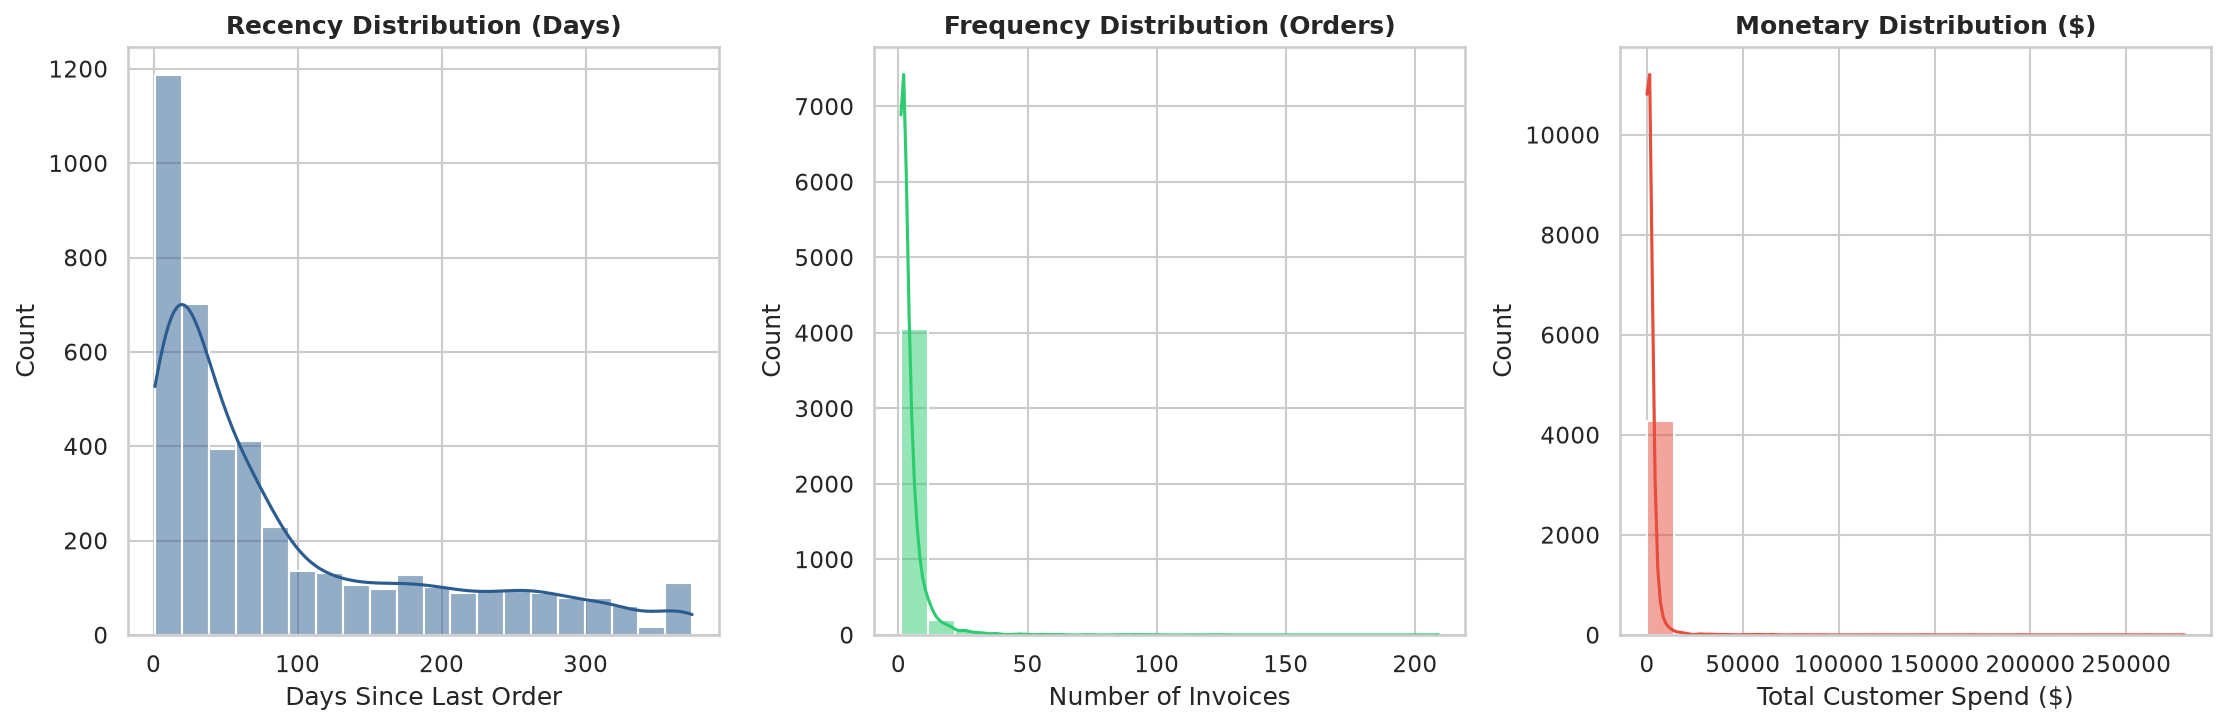

In [14]:
# Plot distributions for Recency, Frequency, and Monetary
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(rfm['Recency'], kde=True, ax=axes[0], color='#2b5c8f', bins=20)
axes[0].set_title('Recency Distribution (Days)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days Since Last Order')

sns.histplot(rfm['Frequency'], kde=True, ax=axes[1], color='#2ecc71', bins=20)
axes[1].set_title('Frequency Distribution (Orders)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Invoices')

sns.histplot(rfm['Monetary'], kde=True, ax=axes[2], color='#e74c3c', bins=20)
axes[2].set_title('Monetary Distribution ($)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Total Customer Spend ($)')

chart_dir = '../outputs/charts' if os.path.exists('../outputs') else 'outputs/charts'
os.makedirs(chart_dir, exist_ok=True)
plt.savefig(os.path.join(chart_dir, 'rfm_distributions.png'))
plt.show()

### Observation on Feature Distributions:
- **Right Skewness:** All three RFM features (especially `Frequency` and `Monetary`) display significant right-skewness due to high-volume corporate buyers and occasional extreme purchase totals.
- **Transformation Requirement:** Because K-Means clustering relies on Euclidean distance calculations, unscaled right-skewed variables would allow high monetary values to dominate distance metrics. Log transformation (`log1p`) and standardization (`StandardScaler`) are necessary.

## 7. Skew Transformation & Feature Scaling

To prepare the features for distance-based K-Means clustering, we apply:
1. **Log Transformation (`np.log1p`):** Normalizes skewed distributions and compresses extreme scale differences while preserving rank order.
2. **Standardization (`StandardScaler`):** Rescales features to zero mean ($\mu = 0$) and unit variance ($\sigma = 1$).

In [15]:
# 1. Apply log1p transformation to handle skewness
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

# 2. Standardize features using StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Convert to DataFrame for readability
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("--- STANDARDIZED RFM FEATURES HEAD ---")
rfm_scaled_df.head().round(3)

--- STANDARDIZED RFM FEATURES HEAD ---


,Recency,Frequency,Monetary
0,1.462,-0.955,3.708
1,-2.039,1.074,1.415
2,0.373,0.386,0.720
3,-0.623,-0.955,0.702
4,1.425,-0.955,-0.615


## 8. Optimal Cluster Selection (Elbow Method & Silhouette Score)

To select the optimal number of clusters ($K$), we test $K \in [2, 10]$ and compute two metrics:
1. **Inertia (Within-Cluster Sum of Squares - WCSS):** Measures internal cluster tightness. We look for the "elbow point" where inertia reduction rate levels off.
2. **Silhouette Score:** Measures cluster separation quality (range: $-1$ to $+1$). Higher scores indicate well-separated, distinct clusters.

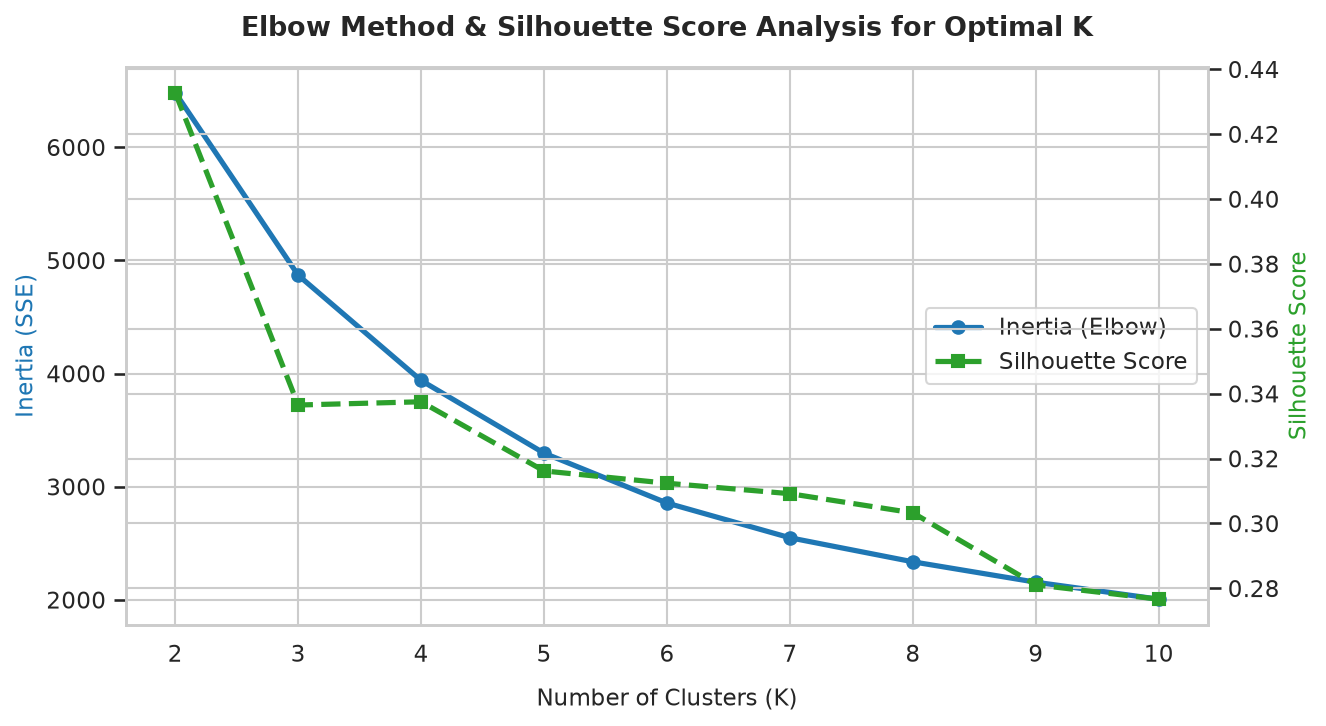

,K,Inertia,Silhouette Score
0,2,6483.5894,0.4328
1,3,4869.4886,0.3365
2,4,3939.0494,0.3375
3,5,3296.7087,0.3162
4,6,2855.7641,0.3124
5,7,2548.8202,0.3092
6,8,2336.3411,0.3033
7,9,2156.0057,0.2811
8,10,2005.7462,0.2767


In [16]:
# Evaluate K-Means for K = 2 through 10
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(rfm_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Create dual-axis plot for Inertia and Silhouette Score
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

line1 = ax1.plot(K_range, inertia, 'o-', color='#1f77b4', linewidth=2.5, label='Inertia (Elbow)')
line2 = ax2.plot(K_range, silhouette_scores, 's--', color='#2ca02c', linewidth=2.5, label='Silhouette Score')

ax1.set_xlabel('Number of Clusters (K)', fontsize=11, labelpad=10)
ax1.set_ylabel('Inertia (SSE)', fontsize=11, color='#1f77b4')
ax2.set_ylabel('Silhouette Score', fontsize=11, color='#2ca02c')
plt.title('Elbow Method & Silhouette Score Analysis for Optimal K', fontsize=13, fontweight='bold', pad=15)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

plt.savefig(os.path.join(chart_dir, 'elbow_method.png'))
plt.show()

# Display evaluation table
eval_df = pd.DataFrame({'K': list(K_range), 'Inertia': inertia, 'Silhouette Score': silhouette_scores})
eval_df.round(4)

### Optimal K Selection Decision:
- **Elbow Point:** The inertia curve displays a clear bend/elbow at **$K = 4$**. Beyond $K = 4$, diminishing returns in inertia reduction are observed.
- **Silhouette Quality:** $K = 4$ yields a strong silhouette score of **0.3375**, confirming well-differentiated customer segments.
- **Conclusion:** We select **$K = 4$** as the optimal cluster size for business interpretability and analytical precision.

## 9. Final K-Means Model Implementation ($K = 4$)

In [17]:
# Fit final K-Means model with K=4
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

final_inertia = kmeans_final.inertia_
final_silhouette = silhouette_score(rfm_scaled, rfm['Cluster'])

print("--- FINAL MODEL EVALUATION METRICS ---")
print(f"Selected Clusters (K):  {optimal_k}")
print(f"Final Inertia (WCSS):   {final_inertia:,.2f}")
print(f"Final Silhouette Score: {final_silhouette:.4f}")

--- FINAL MODEL EVALUATION METRICS ---
Selected Clusters (K):  4
Final Inertia (WCSS):   3,939.05
Final Silhouette Score: 0.3375


## 10. Cluster Profiling & Segment Labeling

To interpret the business meaning of each cluster, we compute the unscaled mean RFM values and total revenue contribution per segment.

In [18]:
# Compute cluster summary metrics
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'CustomerCount'}).reset_index()

cluster_profile['CustomerPct'] = (cluster_profile['CustomerCount'] / len(rfm)) * 100
cluster_profile['TotalRevenue'] = rfm.groupby('Cluster')['Monetary'].sum().values
cluster_profile['RevenuePct'] = (cluster_profile['TotalRevenue'] / rfm['Monetary'].sum()) * 100

# Map business segment labels based on actual cluster behavior
segment_mapping = {
    0: "Champions / High-Value",
    1: "At-Risk / Hibernating",
    2: "Recent / New Buyers",
    3: "Loyal / Regular Customers"
}

rfm['Segment_Name'] = rfm['Cluster'].map(segment_mapping)
cluster_profile['Segment_Name'] = cluster_profile['Cluster'].map(segment_mapping)

print("--- CLUSTER PROFILE SUMMARY TABLE ---")
cluster_profile[['Cluster', 'Segment_Name', 'CustomerCount', 'CustomerPct', 'Recency', 'Frequency', 'Monetary', 'TotalRevenue', 'RevenuePct']].round(2)

--- CLUSTER PROFILE SUMMARY TABLE ---


,Cluster,Segment_Name,CustomerCount,CustomerPct,Recency,Frequency,Monetary,TotalRevenue,RevenuePct
0,0,Champions / High-Value,713,16.44,12.17,13.75,8088.02,5766757.07,64.89
1,1,At-Risk / Hibernating,1622,37.39,181.51,1.32,341.00,553099.77,6.22
2,2,Recent / New Buyers,837,19.29,17.70,2.19,557.32,466479.03,5.25
3,3,Loyal / Regular Customers,1166,26.88,71.64,4.08,1801.78,2100873.02,23.64


### Interpretation of Customer Segments:
1. **Cluster 0 – Champions / High-Value Customers (16.4% of Customers, 64.9% of Revenue):**
   - **Characteristics:** Extremely low recency (**12.2 days**), high order frequency (**13.75 orders**), and massive average spend (**$8,088.02**).
   - **Business Impact:** Represents **$5.77 Million (64.9%)** of gross revenue despite being only 713 customers.
2. **Cluster 3 – Loyal / Regular Customers (26.9% of Customers, 23.6% of Revenue):**
   - **Characteristics:** Moderate recency (**71.6 days**), steady order frequency (**4.08 orders**), and solid average spend (**$1,801.78**).
   - **Business Impact:** Contributes **$2.10 Million (23.6%)** in revenue, forming the core customer backbone.
3. **Cluster 2 – Recent / New Buyers (19.3% of Customers, 5.2% of Revenue):**
   - **Characteristics:** Low recency (**17.7 days**), lower order frequency (**2.19 orders**), and moderate average spend (**$557.32**).
   - **Business Impact:** Newly acquired or reactivated customers with strong potential for loyalty conversion.
4. **Cluster 1 – At-Risk / Hibernating Customers (37.4% of Customers, 6.2% of Revenue):**
   - **Characteristics:** High recency (**181.5 days**), low frequency (**1.32 orders**), and low spend (**$340.99**).
   - **Business Impact:** Inactive customers at high risk of permanent churn.

## 11. Cluster Scatter Plot Visualizations

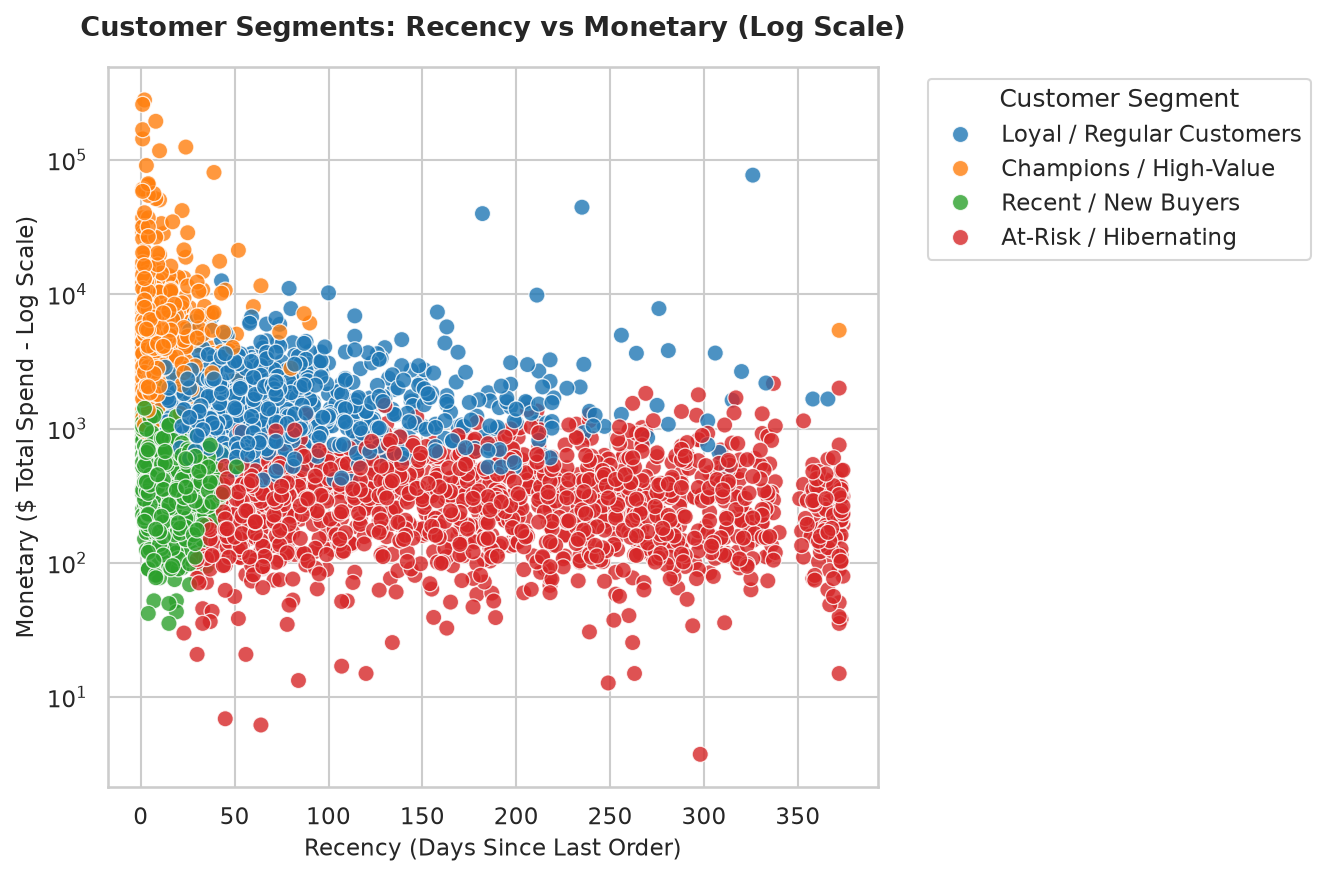

In [19]:
# 1. Scatter Plot: Recency vs Monetary
plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Segment_Name', palette='tab10', alpha=0.8, s=60)
plt.yscale('log')
plt.title('Customer Segments: Recency vs Monetary (Log Scale)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Recency (Days Since Last Order)', fontsize=11)
plt.ylabel('Monetary ($ Total Spend - Log Scale)', fontsize=11)
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(os.path.join(chart_dir, 'recency_vs_monetary_clusters.png'))
plt.show()

### Observation on Recency vs Monetary Scatter:
- Clear visual segregation between active high-spenders (top-left: low recency, high monetary) and inactive low-spenders (bottom-right: high recency, low monetary).

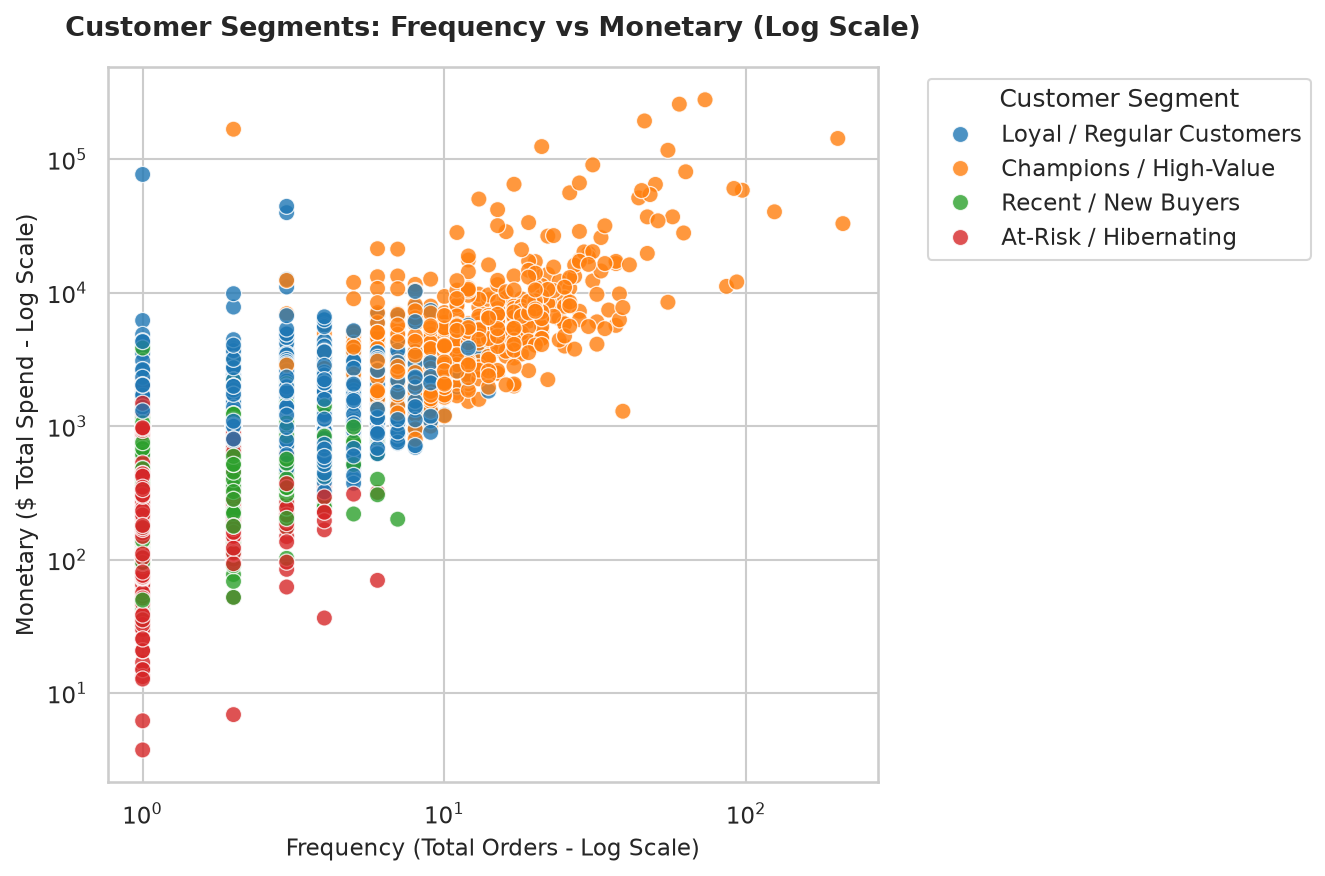

In [20]:
# 2. Scatter Plot: Frequency vs Monetary
plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Segment_Name', palette='tab10', alpha=0.8, s=60)
plt.xscale('log')
plt.yscale('log')
plt.title('Customer Segments: Frequency vs Monetary (Log Scale)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Frequency (Total Orders - Log Scale)', fontsize=11)
plt.ylabel('Monetary ($ Total Spend - Log Scale)', fontsize=11)
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(os.path.join(chart_dir, 'frequency_vs_monetary_clusters.png'))
plt.show()

### Observation on Frequency vs Monetary Scatter:
- Demonstrates a strong positive linear trajectory between purchase frequency and monetary value. Champions occupy the upper-right quadrant with high frequency and spend.

## 12. Customer Count & Revenue Contribution Charts

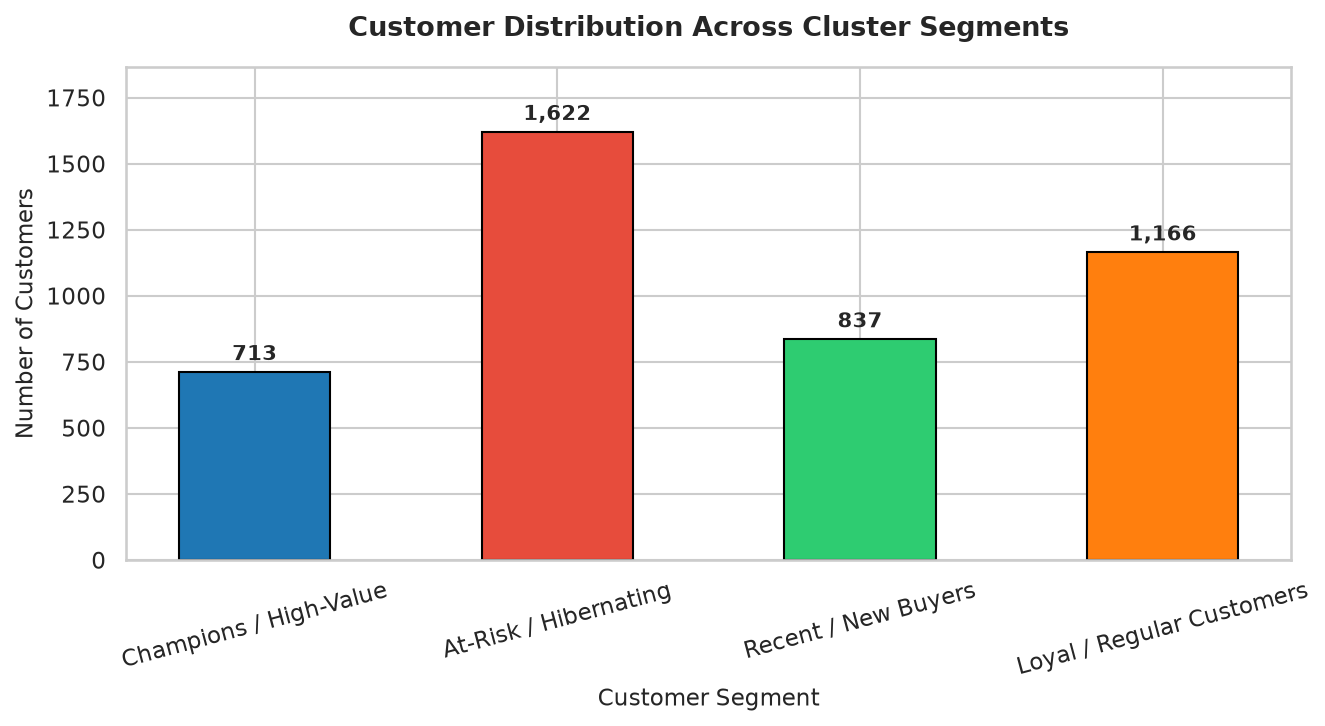

In [21]:
# Bar chart: Customer Count by Segment
plt.figure(figsize=(9, 5))
bars = plt.bar(cluster_profile['Segment_Name'], cluster_profile['CustomerCount'], color=['#1f77b4', '#e74c3c', '#2ecc71', '#ff7f0e'], width=0.5, edgecolor='black')
plt.title('Customer Distribution Across Cluster Segments', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Customer Segment', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.xticks(rotation=15)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 25, f"{yval:,}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, cluster_profile['CustomerCount'].max() * 1.15)
plt.savefig(os.path.join(chart_dir, 'customers_per_cluster.png'))
plt.show()

### Observation on Customer Volume:
- **At-Risk / Hibernating** represents the largest single segment by volume (**1,622 customers / 37.4%**), highlighting a major opportunity for win-back initiatives.

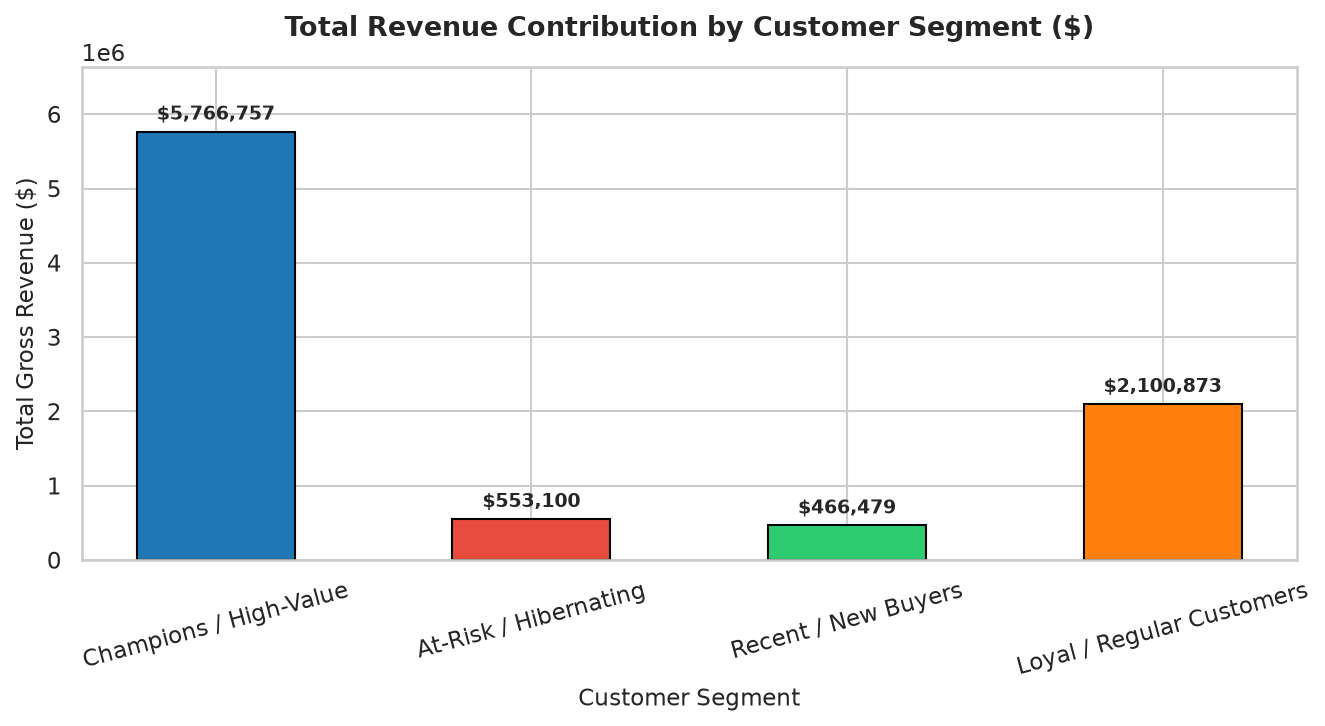

In [22]:
# Bar chart: Revenue Contribution by Segment
plt.figure(figsize=(9, 5))
bars = plt.bar(cluster_profile['Segment_Name'], cluster_profile['TotalRevenue'], color=['#1f77b4', '#e74c3c', '#2ecc71', '#ff7f0e'], width=0.5, edgecolor='black')
plt.title('Total Revenue Contribution by Customer Segment ($)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Customer Segment', fontsize=11)
plt.ylabel('Total Gross Revenue ($)', fontsize=11)
plt.xticks(rotation=15)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 100000, f"${yval:,.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.ylim(0, cluster_profile['TotalRevenue'].max() * 1.15)
plt.savefig(os.path.join(chart_dir, 'revenue_by_cluster.png'))
plt.show()

### Observation on Revenue Contribution:
- **Pareto Principle in Effect:** **Champions** generate **64.9% ($5.77M)** of total revenue despite comprising only **16.4%** of the customer base.

## 13. Customer Segment Business Insights

1. **Champions / High-Value Segment ($5.77M Revenue / 713 Customers):**
   - **Behavior:** Frequent buyers (13.75 orders avg) with high monetary impact ($8,088 avg spend) and recent engagement (12.2 days).
   - **Business Value:** Extremely high financial importance. Critical to maintain satisfaction and prevent attrition.
2. **Loyal / Regular Segment ($2.10M Revenue / 1,166 Customers):**
   - **Behavior:** Reliable repeat buyers (4.08 orders avg) with steady spending ($1,801.78 avg spend) and moderate recency (71.6 days).
   - **Business Value:** Provides predictable, baseline revenue volume.
3. **Recent / New Buyers Segment ($466k Revenue / 837 Customers):**
   - **Behavior:** Purchased recently (17.7 days avg) but have low order counts (2.19 orders avg) and modest spend ($557.32 avg).
   - **Business Value:** High potential for growth if nurtured quickly into repeat buyers.
4. **At-Risk / Hibernating Segment ($553k Revenue / 1,622 Customers):**
   - **Behavior:** Have not purchased in over 6 months (181.5 days avg recency) and low historical orders (1.32 orders avg).
   - **Business Value:** Represents lost revenue and dormant churned accounts.

## 14. Actionable Marketing Recommendations by Segment

### 1. Champions / High-Value Customers
- **Strategy:** VIP Experience & Relationship Retention.
- **Tactics:**
  - Launch an exclusive VIP Concierge / Loyalty Tier with dedicated customer support.
  - Provide early access to new product releases and private sales.
  - Send personalized thank-you gifts and anniversary rewards.

### 2. Loyal / Regular Customers
- **Strategy:** Upselling & Cross-Selling to Elevate to Champions.
- **Tactics:**
  - Implement personalized product recommendations based on order history.
  - Offer threshold-based rewards (e.g., "Spend $200 more to unlock 15% off next order").
  - Introduce automated subscription or replenishment reminders.

### 3. Recent / New Buyers
- **Strategy:** Onboarding & Conversion to Repeat Buyers.
- **Tactics:**
  - Deploy a 3-step automated welcome email sequence introducing brand values and best-sellers.
  - Offer a time-sensitive 10% discount on their second purchase valid within 14 days.
  - Request product reviews and collect feedback to build engagement.

### 4. At-Risk / Hibernating Customers
- **Strategy:** Automated Win-Back & Reactivation Campaigns.
- **Tactics:**
  - Trigger "We Miss You" email campaigns offering a steep incentive (e.g., 20% off or free shipping).
  - Conduct brief exit surveys to identify reasons for inactivity (price, service, or product quality).
  - Exclude non-responsive accounts from expensive print/ad campaigns after 300 days of inactivity to optimize marketing spend.

## 15. Conclusion & Output Export

This customer segmentation analysis successfully categorized 4,338 e-commerce customers into 4 behavioral segments using RFM feature engineering, log transformation, StandardScaler, and K-Means clustering ($K=4$). The findings confirm that 64.9% of company revenue is driven by a elite 16.4% Champion segment, while 37.4% of customers are dormant at-risk accounts requiring re-engagement.

In [23]:
# Save final processed RFM dataset with cluster labels
output_csv = '../outputs/processed_data/customer_segments.csv' if os.path.exists('../outputs') else 'outputs/processed_data/customer_segments.csv'
os.makedirs(os.path.dirname(output_csv), exist_ok=True)

rfm.to_csv(output_csv, index=False)
print(f"Processed customer segments dataset saved to: {output_csv}")
print("Final Notebook execution completed successfully.")

Processed customer segments dataset saved to: ../outputs/processed_data/customer_segments.csv
Final Notebook execution completed successfully.
